In [5]:
import sys
import pandas as pd
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"

sys.path.append(str(PROJECT_DIR))

import utils
import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import plotting_utils
import stat_utils

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

tf_dna_model_checkpoints = {
    "mESC": CHKPT_DIR / "tf_dna_mm10_3682785" / "epoch=05-val_auroc=0.9765-val_loss=0.1653.ckpt",
    "iPSC": CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"
}

tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3684521" / "epoch=10-val_auroc=0.6134-val_loss=0.6314.ckpt",
        # "E8.5_rep1": CHKPT_DIR / "tf_tg_train_3675640" / "epoch=13-val_auroc=0.7088-val_loss=0.6206.ckpt"
    },
    "iPSC": {
        "WT_D13_rep1": CHKPT_DIR / "iPSC" /"WT_D13_rep1" / "tf_tg_train_WT_D13_rep1_3683642" / "epoch=23-val_auroc=0.7279-val_loss=0.5969.ckpt",
    }
}

### Function to load the trained TF-TG binding model

In [2]:
def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 3) Load the model state from the checkpoint
    state = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )
    lit_model.load_state_dict(state["state_dict"], strict=True)

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

### Function to load a cached dataset (train/val/test)

In [3]:
def load_training_cache_dataset(
    sample_name: str,
    cell_type_cache_dir: Path, 
    split_type: str = "test", 
    subset_size: int = None
    ) -> DataLoader:
    
    assert split_type in ["train", "val", "test"], \
        "split_type must be one of 'train', 'val', or 'test'"
    
    # Load the compact split inputs
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    # Load the lookup tensors
    tf_embeddings_tensor = torch.load(
        cell_type_cache_dir / "tf_embeddings.pt",
        weights_only=True,
    )
    tf_mask_tensor = torch.load(
        cell_type_cache_dir / "tf_masks.pt",
        weights_only=True,
    )
    atac_peak_tensor = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "atac_peak_tensor.pt",
        weights_only=True,
    )

    # Load the metadata
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
        metadata = json.load(f)

    # Load the manifest and verify tensor shapes and dtypes match expectations
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "manifest.json") as f:
        manifest = json.load(f)
    
    assert tuple(manifest["atac_peak_tensor_shape"]) == tuple(atac_peak_tensor.shape)
    assert manifest["atac_peak_tensor_dtype"] == str(atac_peak_tensor.dtype)

    dataset = tftg_dataset_module.TFTGEdgeBagDataset(
        tftg_inputs_test,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor
    )
    
    if subset_size is not None:
        dataset = Subset(dataset, list(range(subset_size)))

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
        )
    
    return loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor


### Run model predictions on the trained dataset

In [8]:
# model_training_sample = "E8.5_rep1"
# evaluation_sample = "E8.5_rep1"

all_comparison_df_list = []

evaluations = {
    "mESC": [
        ("E7.5_rep1", "E7.5_rep1"),
        # ("E7.5_rep1", "E8.5_rep1"),
        # ("E8.5_rep1", "E7.5_rep1"),
        # ("E8.5_rep1", "E8.5_rep1"),
    ],
    "iPSC": [
        ("WT_D13_rep1", "WT_D13_rep1"),
    ]
}

evaluation_cell_type = "mESC"
for model_training_sample, evaluation_sample in evaluations[evaluation_cell_type]:
    print(f"Model {model_training_sample} | Test set {evaluation_sample}")
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[evaluation_cell_type][model_training_sample]
    tf_dna_model_chkpt = tf_dna_model_checkpoints[evaluation_cell_type]

    # print(f"Loading TF→TG model")
    dataset_split_type = "test"
    subset_size = 5000
    
    cell_type_cache_dir = DATA_DIR / f"{evaluation_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = load_tf_tg_regulation_model(tf_dna_model_chkpt, tf_tg_model_chkpt, tf_embeddings_tensor, tf_mask_tensor)

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []

    # print(f"Evaluating on {dataset_split_type} set")
    for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
        batch = tf_to_tg_module.move_batch_to_device(batch, device)

        labels = batch["label"]
        cell_mask = batch["cell_mask"]
        E, C = cell_mask.shape

        edge_logits, _ = model.forward(
            tf_embedding=batch["tf_embedding"],
            tf_mask=batch["tf_mask"],
            peak_sequences=batch["peak_sequences"],
            peak_accessibility=batch["peak_accessibility"],
            peak_distance=batch["peak_distance"],
            tf_expression=batch["tf_expression"],
            tg_expression=batch["tg_expression"],
            peak_mask=batch.get("peak_mask", None),
            cell_mask=cell_mask,
            pooling_mode=pooling_mode,
            pooling_temperature=pooling_temperature,
        )

        loss = criterion(edge_logits, labels)

        total_loss += loss.item() * E
        n_edges += E

        scores = torch.sigmoid(edge_logits)

        all_scores.append(scores.detach().cpu().numpy().ravel())
        all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    mean_loss = total_loss / max(n_edges, 1)

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "recall", "rand_auroc", "rand_auprc"]

    metric_df = metric_df[col_order]


    all_comparison_df_list.append(metric_df)
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df)

Model E7.5_rep1 | Test set E7.5_rep1


/gpfs/Home/esm5360/miniconda3/envs/my_env/lib/python3.10/site-packages/lightning_fabric/utilities/cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Evaluating: 100%|█████████████

,Model,Test Set,auroc,auprc,accuracy,precision,recall,rand_auroc,rand_auprc
0,E7.5_rep1,E7.5_rep1,0.572233,0.455054,0.6418,0.649682,0.055495,0.505406,0.371783


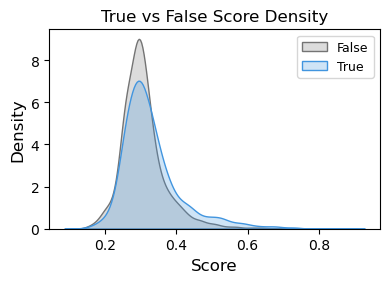

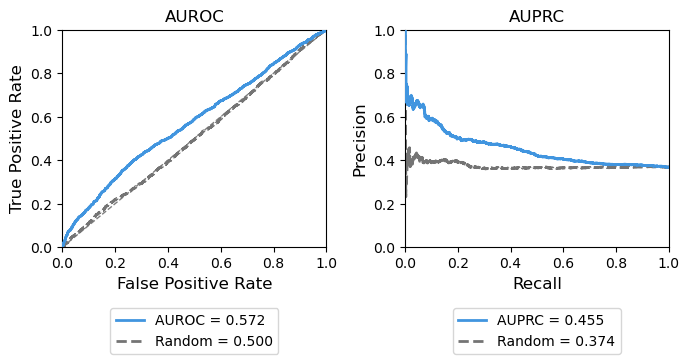

In [9]:
histogram_fig = plotting_utils.plot_score_histograms(
    labels=all_labels_flat,
    scores=all_scores_flat,
    n_bins=25,
    y_log=False,
    panel_kind="kde",
    density=False,
)
histogram_fig.show()

auroc_auprc_fig = plotting_utils.plot_auroc_auprc(
    labels=all_labels_flat,
    scores=all_scores_flat,
)
auroc_auprc_fig.show()

### Evaluate the predictions

In [45]:
importlib.reload(stat_utils)

<module 'stat_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/stat_utils.py'>

In [10]:
metrics = stat_utils.compute_binary_classification_metrics(
    labels=all_labels_flat,
    scores=all_scores_flat,
    score_threshold=score_threshold,
    random_state=42,
)

mean_loss = total_loss / max(n_edges, 1)

metrics["Model"] = model_training_sample
metrics["Test Set"] = evaluation_sample
metrics["loss"] = mean_loss
metrics["score_min"] = float(all_scores_flat.min())
metrics["score_max"] = float(all_scores_flat.max())
metrics["score_mean"] = float(all_scores_flat.mean())
metrics["score_std"] = float(all_scores_flat.std())
metrics["n_pred_pos"] = int((all_scores_flat >= score_threshold).sum())
metrics["n_pred_neg"] = int((all_scores_flat < score_threshold).sum())

metric_df = pd.DataFrame([metrics])

col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "rand_auroc", "rand_auprc"]

metric_df = metric_df[col_order]


all_comparison_df_list.append(metric_df)

print("Final Test Metrics:")
display(metric_df.T)

Final Test Metrics:


,0
Model,E7.5_rep1
Test Set,E7.5_rep1
auroc,0.572233
auprc,0.455054
accuracy,0.6418
precision,0.649682
rand_auroc,0.505406
rand_auprc,0.371783


In [44]:
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)
display(full_comparison_df)

,Model,Test Set,auroc,auprc,accuracy,precision,rand_auroc,rand_auprc
0,E7.5_rep1,E7.5_rep1,0.696399,0.577159,0.6708,0.698347,0.519975,0.381786
1,E7.5_rep1,E8.5_rep1,0.621752,0.629031,0.5656,0.661054,0.501131,0.519073
2,E8.5_rep1,E7.5_rep1,0.636114,0.489747,0.6294,0.493907,0.526398,0.390878
3,E8.5_rep1,E8.5_rep1,0.690027,0.686342,0.6314,0.638061,0.494796,0.520802
